In [ ]:
# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import library scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)

# Setting tampilan
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


In [ ]:
# Load dataset
df = pd.read_csv('manufacturing_defect_dataset.csv')

# Tampilkan informasi awal
print("Ukuran dataset:", df.shape)
print("\n5 Baris Pertama:")
df.head()

Ukuran dataset: (3240, 17)

5 Baris Pertama:


,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1


In [ ]:
# Informasi tipe data dan missing value
print("Informasi Dataset:")
df.info()

# Statistik deskriptif
print("\nStatistik Deskriptif:")
df.describe()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  Ad

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
count,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000
mean,548.523148,12423.018476,89.833290,2.558951,2.749116,80.134272,11.476543,2.501373,6.019662,0.050878,90.040115,4.591667,2988.494453,0.299776,5.472098,299.515479,0.840432
std,262.402073,4308.051904,5.759143,1.705804,1.310154,11.611750,6.872684,1.443684,2.329791,0.028797,5.723600,2.896313,1153.420820,0.116400,2.598212,116.379905,0.366261
min,100.000000,5000.174521,80.004820,0.000000,0.500710,60.010098,0.000000,0.001665,2.001611,0.000002,80.004960,0.000000,1000.720156,0.100238,1.000151,100.211137,0.000000
25%,322.000000,8728.829280,84.869219,1.000000,1.598033,70.103420,5.750000,1.264597,3.983249,0.026200,85.180203,2.000000,1988.140273,0.200502,3.228507,194.922058,1.000000
50%,549.000000,12405.204656,89.704861,3.000000,2.708775,80.265312,12.000000,2.465151,6.022389,0.051837,90.125743,5.000000,2996.822301,0.297470,5.437134,299.728918,1.000000
75%,775.250000,16124.462428,94.789936,4.000000,3.904533,90.353822,17.000000,3.774861,8.050222,0.075473,95.050838,7.000000,3984.788299,0.402659,7.741006,403.178283,1.000000
max,999.000000,19993.365549,99.989214,5.000000,4.998529,99.996993,23.000000,4.997591,9.998577,0.099997,99.996786,9.000000,4997.074741,0.499500,9.999749,499.982782,1.000000


In [ ]:
# Cek missing value
print("Jumlah Missing Value per Kolom:")
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "Tidak ada missing value!")

# Cek duplikat
print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

Jumlah Missing Value per Kolom:
Tidak ada missing value!

Jumlah Data Duplikat: 0


Distribusi Target (DefectStatus):
DefectStatus
1    2723
0     517
Name: count, dtype: int64

Persentase:
DefectStatus
1    84.04321
0    15.95679
Name: proportion, dtype: float64


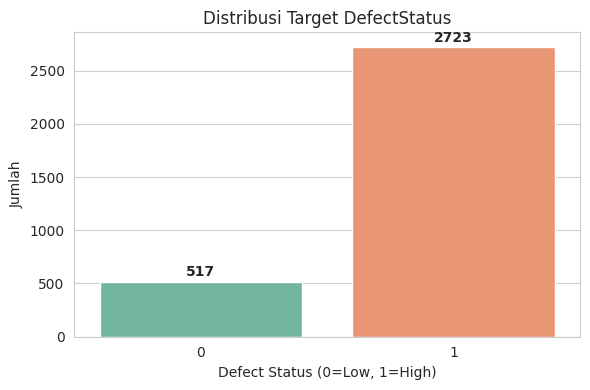

In [ ]:
# Distribusi target
print("Distribusi Target (DefectStatus):")
print(df['DefectStatus'].value_counts())
print(f"\nPersentase:")
print(df['DefectStatus'].value_counts(normalize=True) * 100)

# Visualisasi
plt.figure(figsize=(6, 4))
sns.countplot(x='DefectStatus', data=df, palette='Set2')
plt.title('Distribusi Target DefectStatus')
plt.xlabel('Defect Status (0=Low, 1=High)')
plt.ylabel('Jumlah')
for i, v in enumerate(df['DefectStatus'].value_counts().sort_index()):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

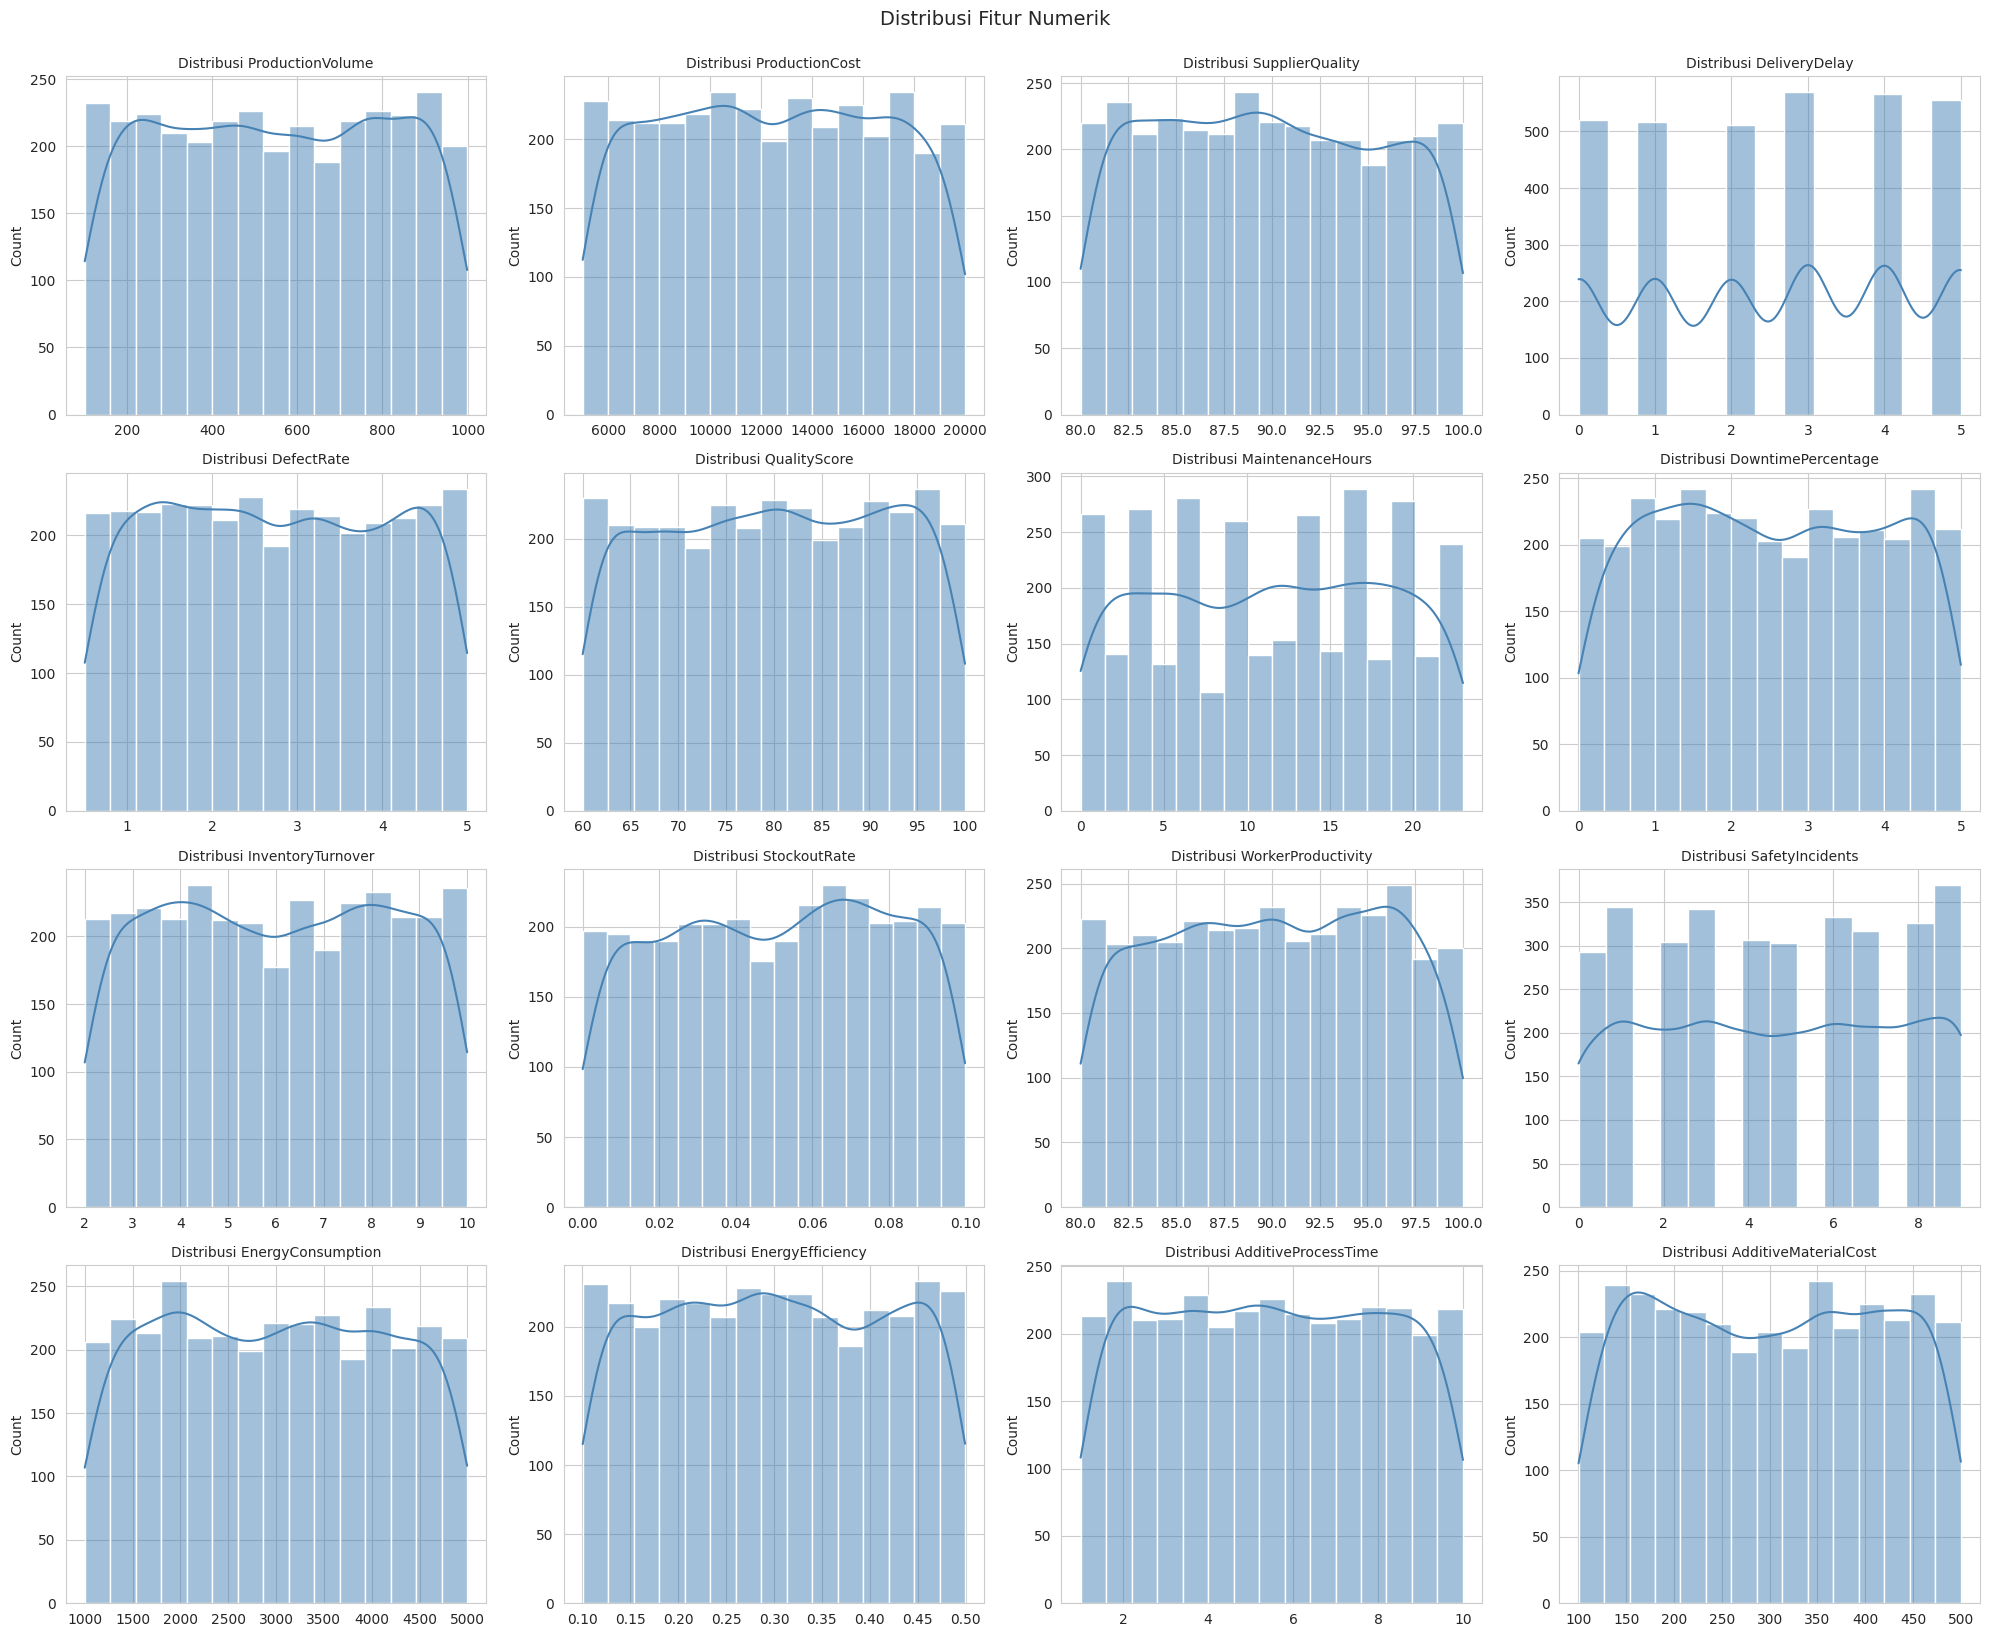

In [ ]:
# Pilih fitur numerik (semua kecuali target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('DefectStatus')

# Histogram distribusi
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}', fontsize=10)
    axes[i].set_xlabel('')

# Hapus subplot kosong
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, y=1.02)
plt.show()

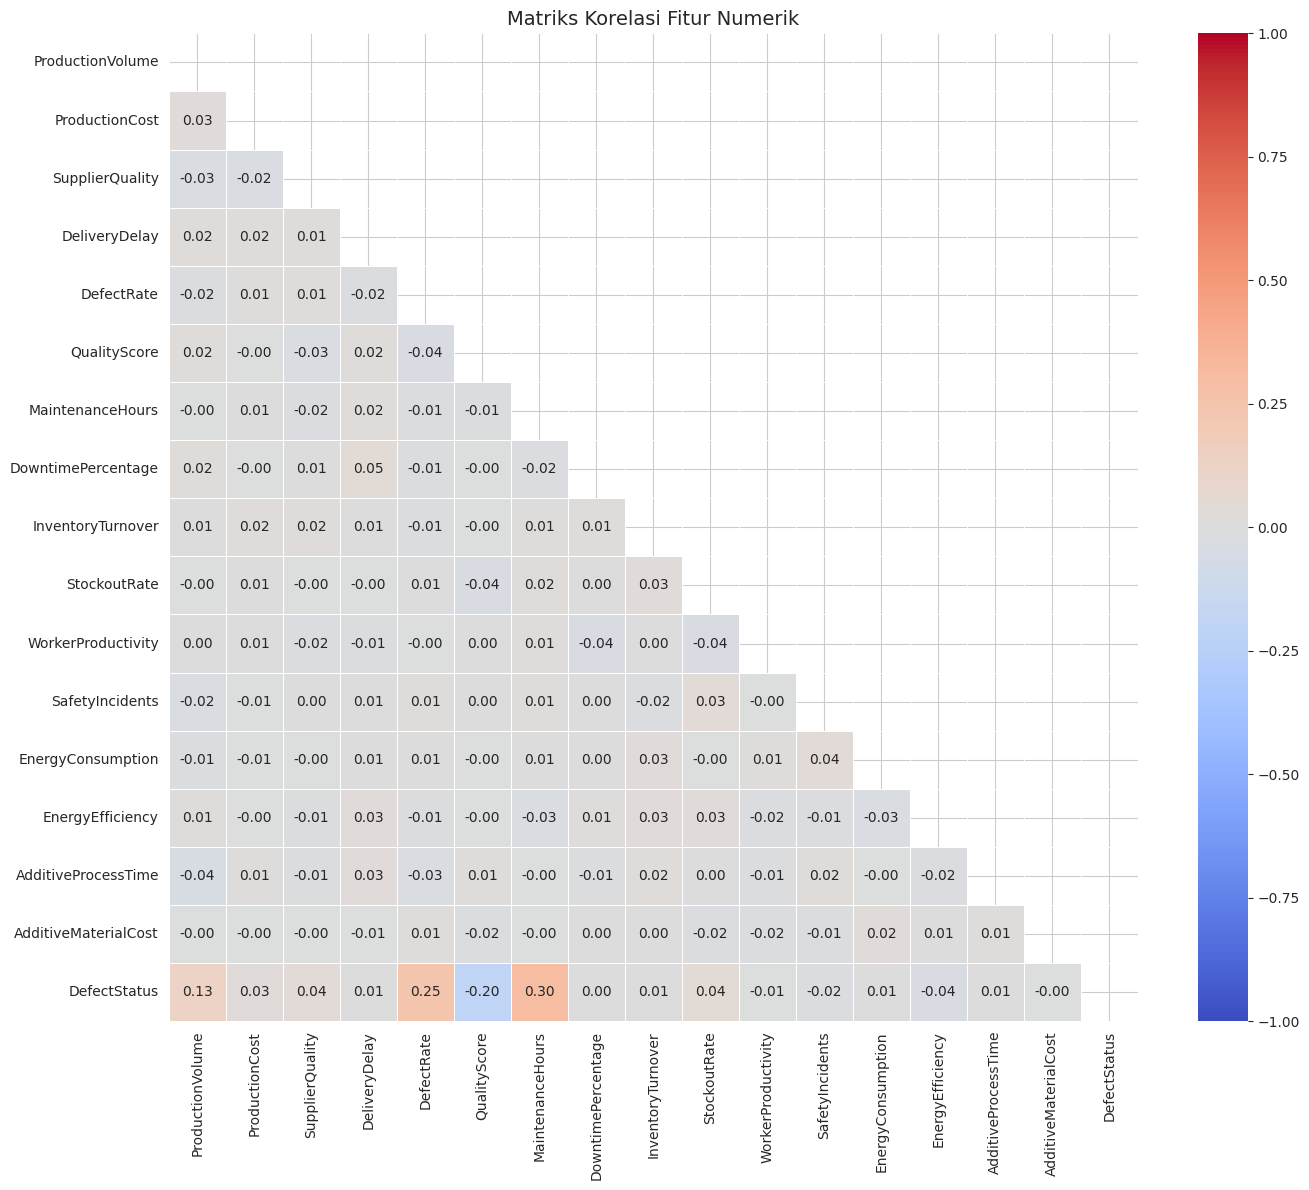

In [ ]:
# Heatmap korelasi fitur numerik
plt.figure(figsize=(14, 12))
correlation = df[numeric_cols + ['DefectStatus']].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

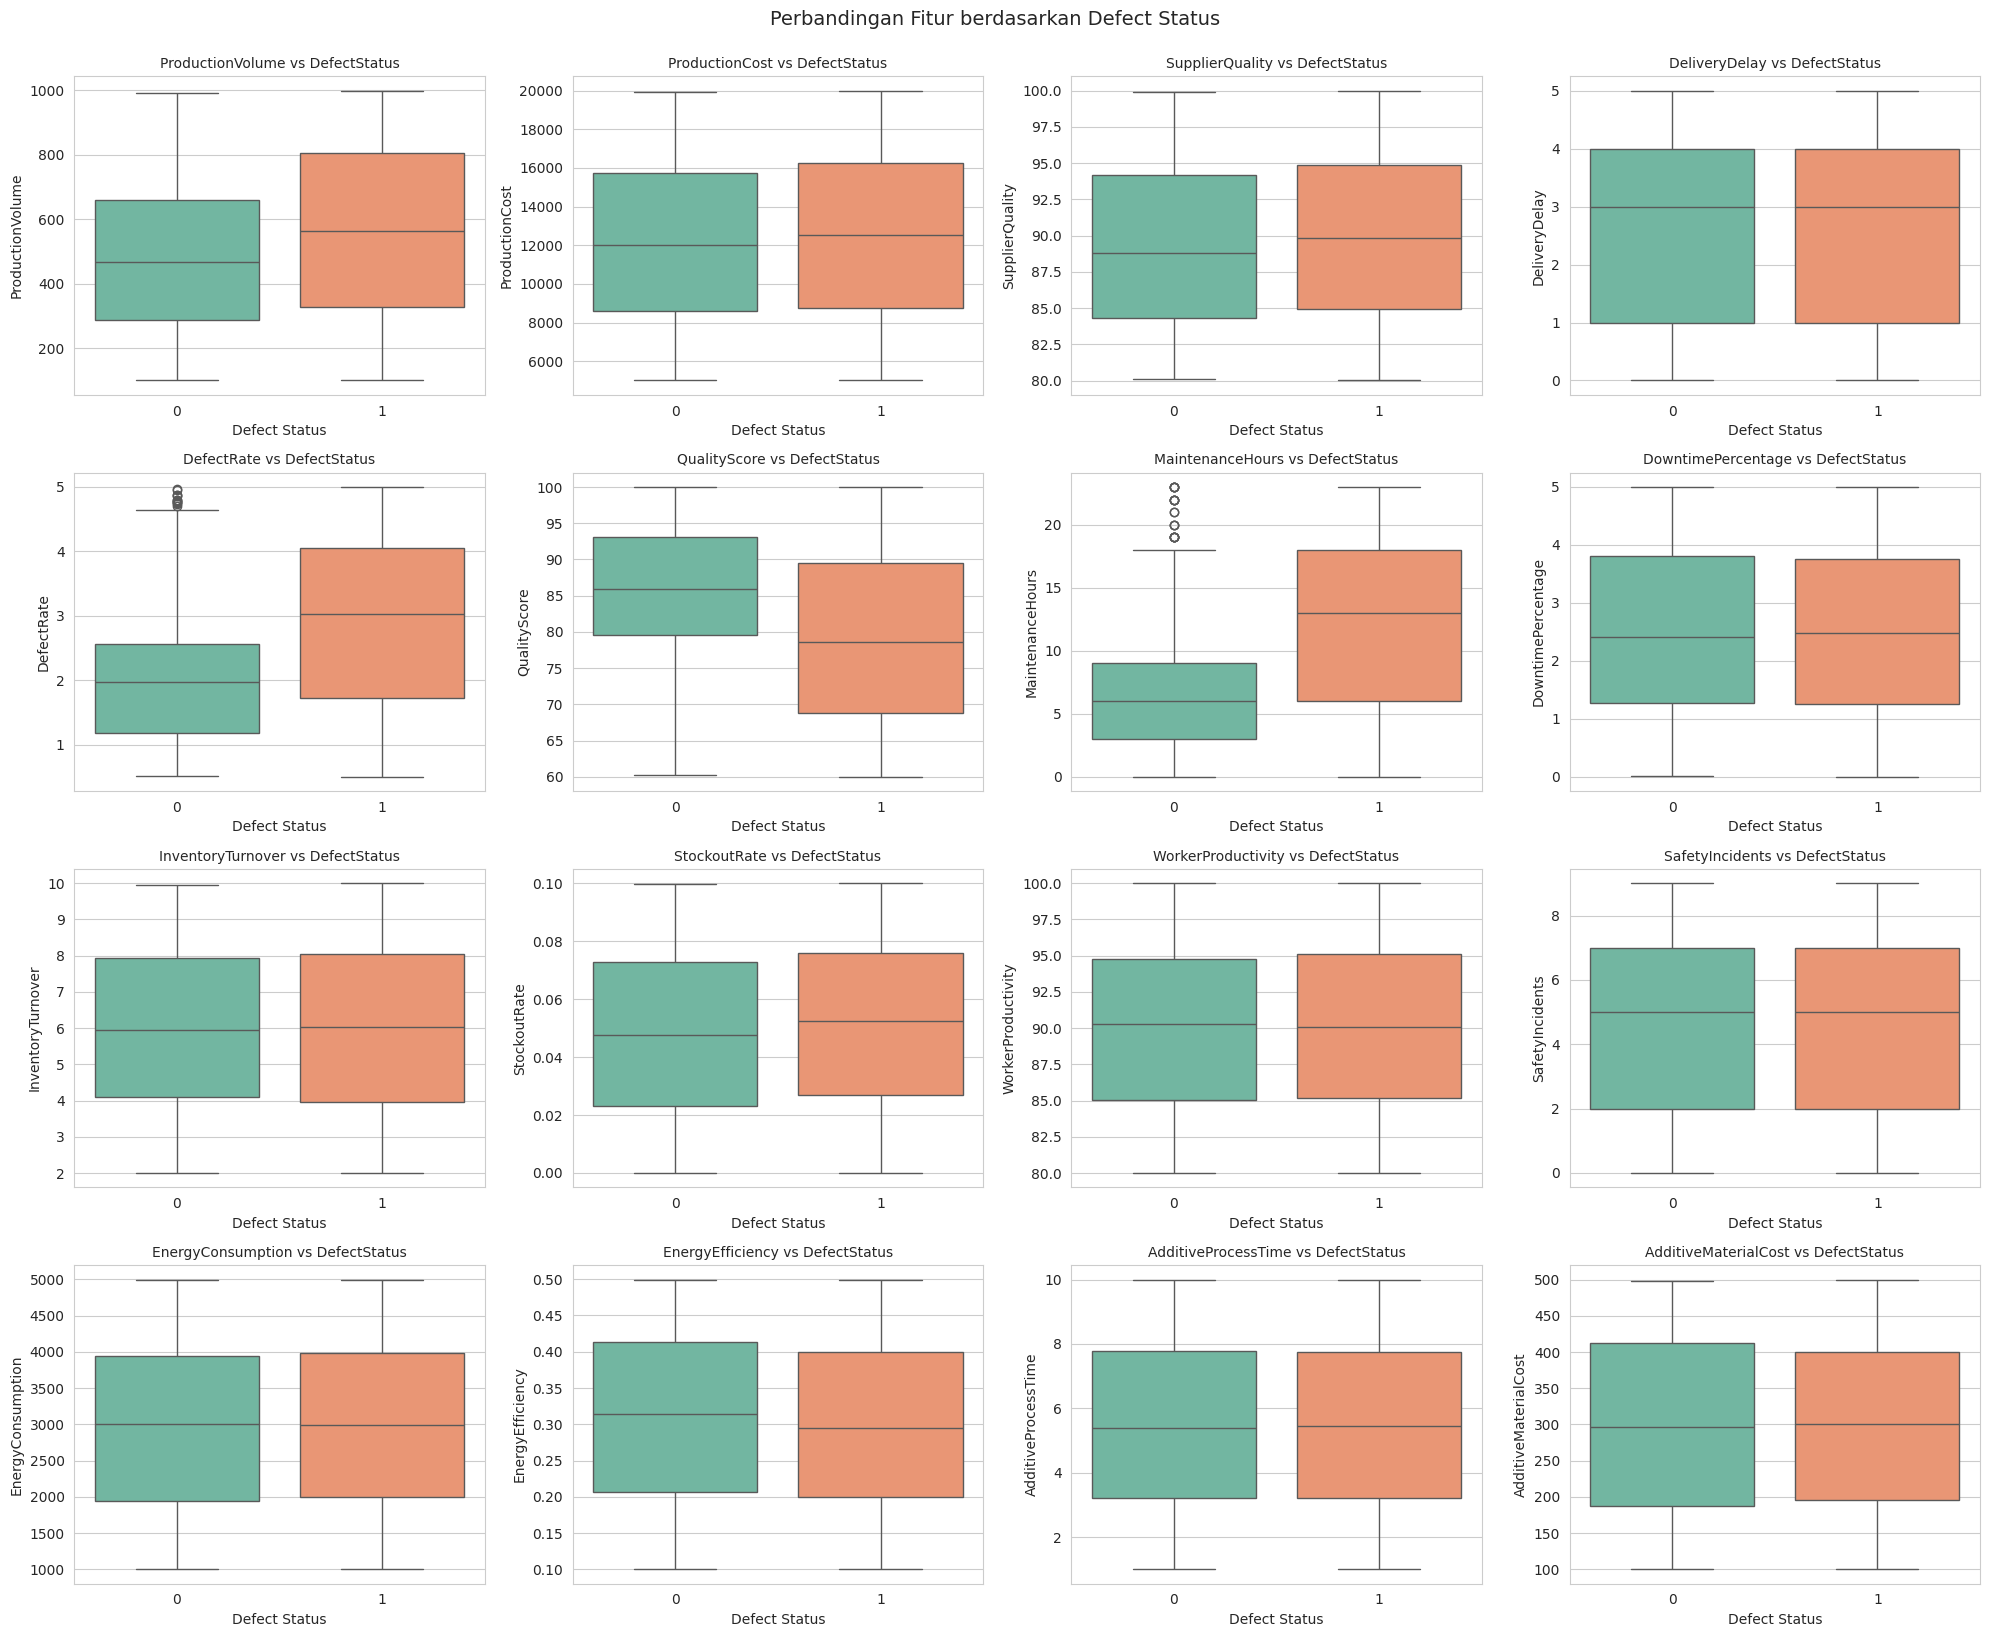

In [ ]:
# Boxplot fitur vs target
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='DefectStatus', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs DefectStatus', fontsize=10)
    axes[i].set_xlabel('Defect Status')

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Perbandingan Fitur berdasarkan Defect Status', fontsize=14, y=1.02)
plt.show()

In [ ]:
# Fitur baru: total cost
df['Total_Cost'] = df['ProductionVolume'] * df['ProductionCost']

# Fitur baru: efficiency ratio
df['Efficiency_Ratio'] = df['WorkerProductivity'] / (df['EnergyConsumption'] + 1)

# Fitur baru: quality index
df['Quality_Index'] = df['QualityScore'] / (df['DefectRate'] + 1)

# Fitur baru: maintenance intensity
df['Maintenance_Intensity'] = df['MaintenanceHours'] / (df['DowntimePercentage'] + 1)

print("Fitur baru yang dibuat:")
print(df[['Total_Cost', 'Efficiency_Ratio', 'Quality_Index', 'Maintenance_Intensity']].describe())

Fitur baru yang dibuat:
         Total_Cost  Efficiency_Ratio  Quality_Index  Maintenance_Intensity
count  3.240000e+03       3240.000000    3240.000000            3240.000000
mean   6.847746e+06          0.036326      24.775336               4.129230
std    4.262288e+06          0.017744      11.078886               3.628246
min    5.300488e+05          0.016262      10.283428               0.000000
25%    3.442429e+06          0.022630      16.263507               1.579725
50%    5.930295e+06          0.030356      21.522663               3.298635
75%    9.622630e+06          0.045006      30.520123               5.418093
max    1.969984e+07          0.096917      65.665111              22.351118


In [ ]:
# Cek kolom yang tersedia
print("Kolom setelah feature engineering:")
print(df.columns.tolist())

# Hapus kolom jika ada identifier unik (tidak ada dalam dataset ini)
# df_clean = df.drop(['ID'], axis=1)  # Jika ada

df_clean = df.copy()
print(f"\nShape df_clean: {df_clean.shape}")

Kolom setelah feature engineering:
['ProductionVolume', 'ProductionCost', 'SupplierQuality', 'DeliveryDelay', 'DefectRate', 'QualityScore', 'MaintenanceHours', 'DowntimePercentage', 'InventoryTurnover', 'StockoutRate', 'WorkerProductivity', 'SafetyIncidents', 'EnergyConsumption', 'EnergyEfficiency', 'AdditiveProcessTime', 'AdditiveMaterialCost', 'DefectStatus', 'Total_Cost', 'Efficiency_Ratio', 'Quality_Index', 'Maintenance_Intensity']

Shape df_clean: (3240, 21)


In [ ]:
# Tentukan fitur dan target
feature_cols = [col for col in df_clean.columns if col != 'DefectStatus']
X = df_clean[feature_cols]
y = df_clean['DefectStatus']

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print(f"\nJumlah fitur: {len(feature_cols)}")
print("\nDistribusi Target:")
print(y.value_counts())

Shape X: (3240, 20)
Shape y: (3240,)

Jumlah fitur: 20

Distribusi Target:
DefectStatus
1    2723
0     517
Name: count, dtype: int64


In [ ]:
# Bagi data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])
print("\nDistribusi target di training:")
print(y_train.value_counts(normalize=True))
print("\nDistribusi target di testing:")
print(y_test.value_counts(normalize=True))

Jumlah data training: 2592
Jumlah data testing: 648

Distribusi target di training:
DefectStatus
1    0.840278
0    0.159722
Name: proportion, dtype: float64

Distribusi target di testing:
DefectStatus
1    0.841049
0    0.158951
Name: proportion, dtype: float64


In [ ]:
# Standardisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean training setelah scaling (harus mendekati 0):")
print(X_train_scaled.mean(axis=0).round(4)[:5], "...")
print("\nStd training setelah scaling (harus mendekati 1):")
print(X_train_scaled.std(axis=0).round(4)[:5], "...")

Mean training setelah scaling (harus mendekati 0):
[ 0. -0. -0. -0.  0.] ...

Std training setelah scaling (harus mendekati 1):
[1. 1. 1. 1. 1.] ...


In [ ]:
# Inisialisasi model
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}
# Dictionary untuk menyimpan hasil
results = {}
# Latih dan evaluasi setiap model
for name, model in models.items():
    # Latih model
    model.fit(X_train_scaled, y_train)
    # Prediksi
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
    # Hitung metrik
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_test_proba)
    # Simpan hasil
    results[name] = {
        'model': model,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc,
        'y_test_pred': y_test_pred,
        'y_test_proba': y_test_proba
    }

    print(f"{'='*60}")
    print(f"Model: {name}")
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1-Score       : {f1:.4f}")
    print(f"AUC-ROC        : {auc:.4f}")
    print()

Model: Decision Tree
Train Accuracy : 0.9684
Test Accuracy  : 0.9383
Precision      : 0.9501
Recall         : 0.9780
F1-Score       : 0.9638
AUC-ROC        : 0.8618

Model: K-Nearest Neighbors
Train Accuracy : 0.9132
Test Accuracy  : 0.8796
Precision      : 0.9005
Recall         : 0.9633
F1-Score       : 0.9309
AUC-ROC        : 0.7484

Model: Naive Bayes
Train Accuracy : 0.8877
Test Accuracy  : 0.8704
Precision      : 0.9229
Recall         : 0.9229
F1-Score       : 0.9229
AUC-ROC        : 0.7973

Model: Logistic Regression
Train Accuracy : 0.8808
Test Accuracy  : 0.8796
Precision      : 0.8938
Recall         : 0.9725
F1-Score       : 0.9315
AUC-ROC        : 0.7991

Model: Random Forest
Train Accuracy : 0.9803
Test Accuracy  : 0.9506
Precision      : 0.9508
Recall         : 0.9927
F1-Score       : 0.9713
AUC-ROC        : 0.8163



In [ ]:
# Buat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Acc': [results[m]['train_accuracy'] for m in results],
    'Test Acc': [results[m]['test_accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1_score'] for m in results],
    'AUC-ROC': [results[m]['auc_roc'] for m in results]
}).round(4)

# Hitung selisih (indikasi overfitting)
comparison_df['Overfit Gap'] = (
    comparison_df['Train Acc'] - comparison_df['Test Acc']
).round(4)

comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
print("Perbandingan Model:")
print(comparison_df.to_string(index=False))

Perbandingan Model:
              Model  Train Acc  Test Acc  Precision  Recall  F1-Score  AUC-ROC  Overfit Gap
      Random Forest     0.9803    0.9506     0.9508  0.9927    0.9713   0.8163       0.0297
      Decision Tree     0.9684    0.9383     0.9501  0.9780    0.9638   0.8618       0.0301
Logistic Regression     0.8808    0.8796     0.8938  0.9725    0.9315   0.7991       0.0012
K-Nearest Neighbors     0.9132    0.8796     0.9005  0.9633    0.9309   0.7484       0.0336
        Naive Bayes     0.8877    0.8704     0.9229  0.9229    0.9229   0.7973       0.0173


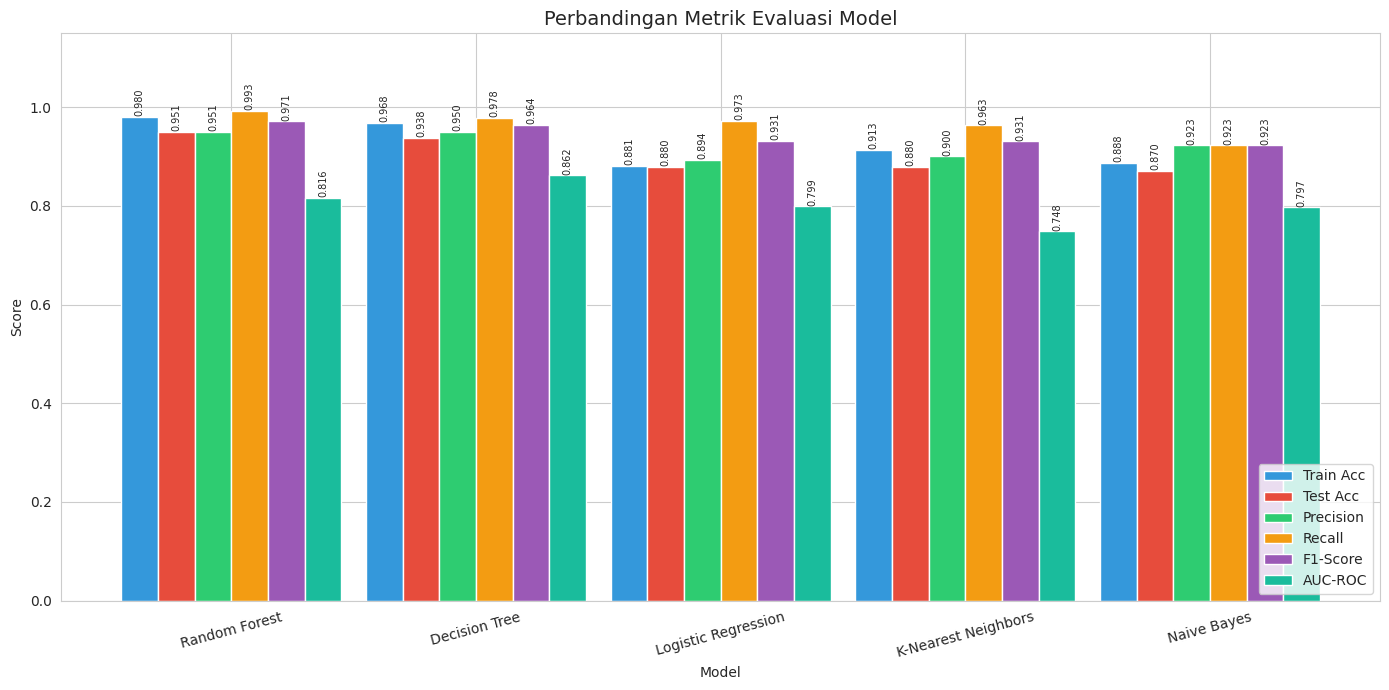

In [ ]:
# Bar chart perbandingan
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(comparison_df))
width = 0.15

metrics = ['Train Acc', 'Test Acc', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width - 2.5*width, comparison_df[metric],
                  width, label=metric, color=color)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 2), textcoords="offset points",
                    ha='center', fontsize=7, rotation=90)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Evaluasi Model', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

Model Terbaik: Random Forest



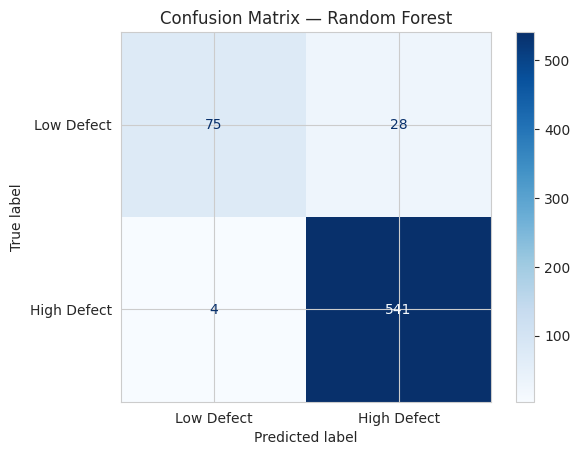

Classification Report — Random Forest:

              precision    recall  f1-score   support

  Low Defect       0.95      0.73      0.82       103
 High Defect       0.95      0.99      0.97       545

    accuracy                           0.95       648
   macro avg       0.95      0.86      0.90       648
weighted avg       0.95      0.95      0.95       648



In [ ]:
# Ambil model terbaik berdasarkan F1-Score
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_y_pred = results[best_model_name]['y_test_pred']

print(f"Model Terbaik: {best_model_name}\n")

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low Defect', 'High Defect'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

# Classification Report
print(f"Classification Report — {best_model_name}:\n")
print(classification_report(y_test, best_y_pred,
                            target_names=['Low Defect', 'High Defect']))

Model Terbaik: Random Forest



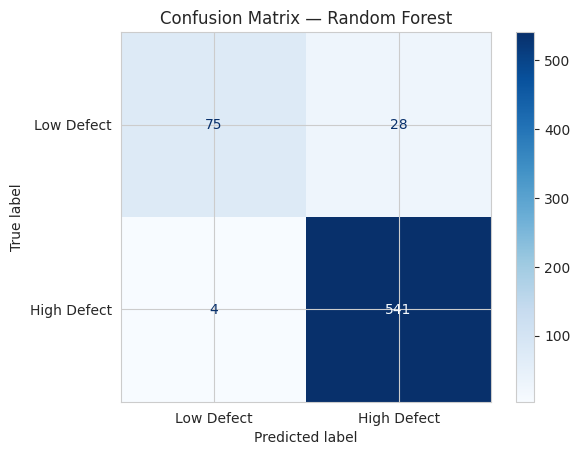

Classification Report — Random Forest:

              precision    recall  f1-score   support

  Low Defect       0.95      0.73      0.82       103
 High Defect       0.95      0.99      0.97       545

    accuracy                           0.95       648
   macro avg       0.95      0.86      0.90       648
weighted avg       0.95      0.95      0.95       648



In [ ]:
# Ambil model terbaik berdasarkan F1-Score
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_y_pred = results[best_model_name]['y_test_pred']

print(f"Model Terbaik: {best_model_name}\n")

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low Defect', 'High Defect'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

# Classification Report
print(f"Classification Report — {best_model_name}:\n")
print(classification_report(y_test, best_y_pred,
                            target_names=['Low Defect', 'High Defect']))

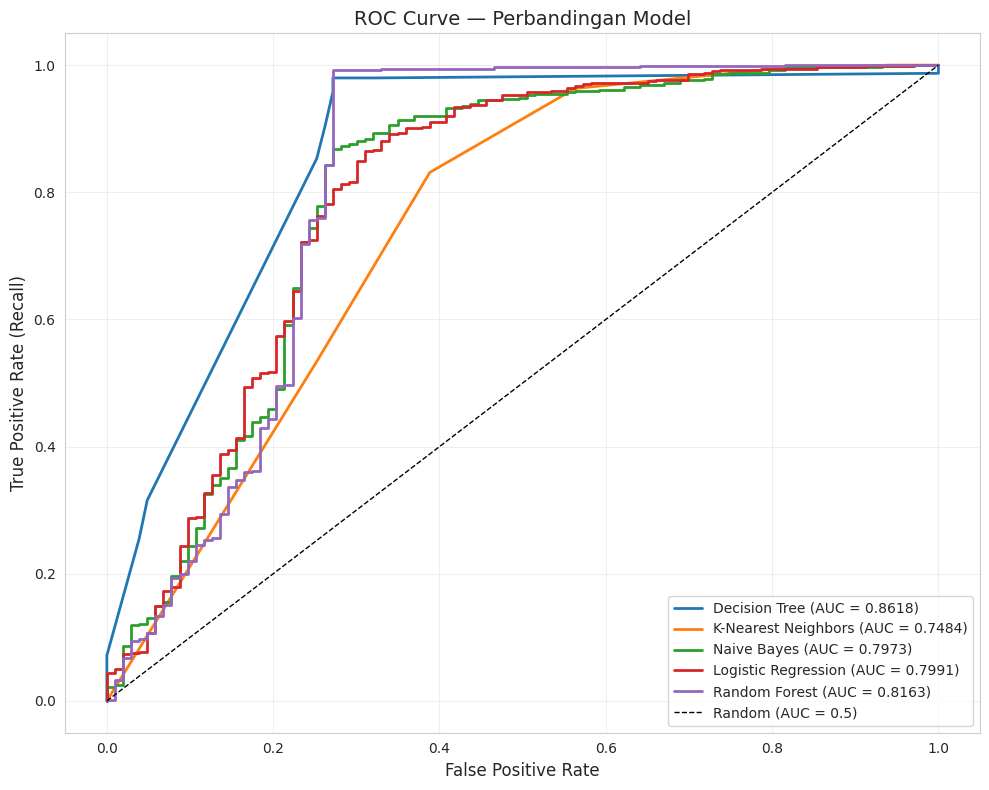

In [ ]:
# ROC Curve untuk semua model
plt.figure(figsize=(10, 8))

for name in results:
    y_proba = results[name]['y_test_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = results[name]['auc_roc']
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — Perbandingan Model', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Feature Importance (Random Forest):
                Fitur  Importance
     MaintenanceHours    0.160067
         QualityScore    0.140420
           DefectRate    0.135335
        Quality_Index    0.132262
Maintenance_Intensity    0.088749
     ProductionVolume    0.081758
           Total_Cost    0.037871
   DowntimePercentage    0.022236
 AdditiveMaterialCost    0.022230
     EnergyEfficiency    0.021863
         StockoutRate    0.021327
    InventoryTurnover    0.019358
       ProductionCost    0.018247
   WorkerProductivity    0.017638
     Efficiency_Ratio    0.017450
      SupplierQuality    0.017013
    EnergyConsumption    0.016674
  AdditiveProcessTime    0.015728
      SafetyIncidents    0.007962
        DeliveryDelay    0.005812


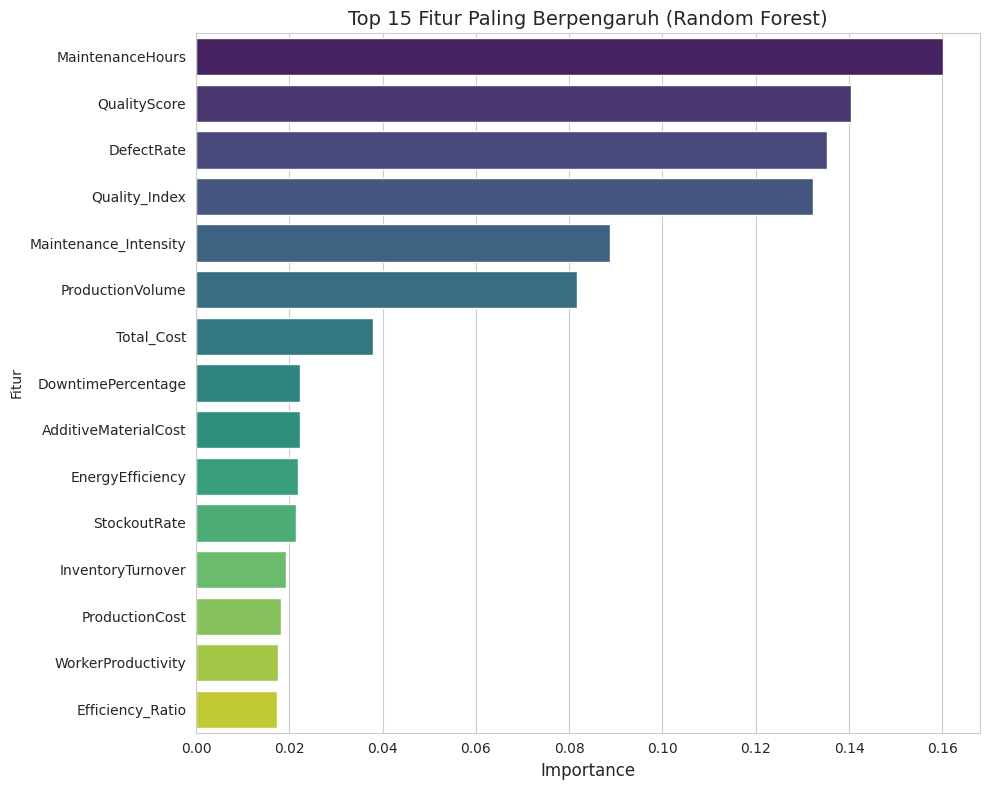

In [ ]:
# Feature importance dari Random Forest
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'Fitur': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(feature_importance.to_string(index=False))

# Visualisasi
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Fitur', data=feature_importance.head(15),
            palette='viridis')
plt.title('Top 15 Fitur Paling Berpengaruh (Random Forest)', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Latih ulang model dengan class_weight='balanced'
models_balanced = {
    'Decision Tree (Balanced)': DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=42),
    'Logistic Regression (Balanced)': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest (Balanced)': RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
}

print("Perbandingan dengan Class Weight Balancing:")
print("=" * 80)

for name, model in models_balanced.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | "
          f"Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

Perbandingan dengan Class Weight Balancing:

Decision Tree (Balanced):
  Accuracy: 0.9074 | Precision: 0.9482 | Recall: 0.9413 | F1: 0.9448 | AUC: 0.8697

Logistic Regression (Balanced):
  Accuracy: 0.7407 | Precision: 0.9394 | Recall: 0.7394 | F1: 0.8275 | AUC: 0.7959

Random Forest (Balanced):
  Accuracy: 0.9506 | Precision: 0.9508 | Recall: 0.9927 | F1: 0.9713 | AUC: 0.8203


In [ ]:
# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation (F1-Score):")
print("=" * 60)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv, scoring='f1')
    print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

5-Fold Cross-Validation (F1-Score):
Decision Tree: F1 = 0.9698 ± 0.0069
K-Nearest Neighbors: F1 = 0.9246 ± 0.0028
Naive Bayes: F1 = 0.9298 ± 0.0102
Logistic Regression: F1 = 0.9303 ± 0.0057
Random Forest: F1 = 0.9753 ± 0.0046


In [ ]:
print("=" * 70)
print("RINGKASAN HASIL PRAKTIKUM — PREDIKSI DEFECT PRODUK MANUFAKTUR")
print("=" * 70)

print(f"""
1. DATASET
   - Sumber: Kaggle — Predicting Manufacturing Defects Dataset
   - Jumlah data: {len(df)} record
   - Jumlah fitur: {len(feature_cols)} fitur
   - Target: DefectStatus (0=Low, 1=High)
   - Class imbalance: {y.value_counts(normalize=True).round(4).to_dict()}

2. PREPROCESSING
   - Missing value: {df.isnull().sum().sum()}
   - Duplikat: {df.duplicated().sum()}
   - Fitur baru dibuat: Total_Cost, Efficiency_Ratio, Quality_Index, Maintenance_Intensity
   - Scaling: StandardScaler
   - Split: 80% train, 20% test (stratified)

3. HASIL PERBANDINGAN MODEL (Test Set)
""")

for _, row in comparison_df.iterrows():
    print(f"   {row['Model']:30s} | F1={row['F1-Score']:.4f} | "
          f"AUC={row['AUC-ROC']:.4f} | Recall={row['Recall']:.4f}")

print(f"""
4. MODEL TERBAIK: {best_model_name}
   - F1-Score: {results[best_model_name]['f1_score']:.4f}
   - AUC-ROC: {results[best_model_name]['auc_roc']:.4f}
   - Recall: {results[best_model_name]['recall']:.4f}

5. FITUR PALING BERPENGARUH (Top 5):
""")

for _, row in feature_importance.head(5).iterrows():
    print(f"   - {row['Fitur']}: {row['Importance']:.4f}")

print(f"""
6. REKOMENDASI
   - Model {best_model_name} direkomendasikan untuk deployment awal.
   - Prioritaskan monitoring pada fitur: {feature_importance.iloc[0]['Fitur']},
     {feature_importance.iloc[1]['Fitur']}, {feature_importance.iloc[2]['Fitur']}.
   - Pertimbangkan SMOTE untuk meningkatkan Recall kelas minoritas.
""")

RINGKASAN HASIL PRAKTIKUM — PREDIKSI DEFECT PRODUK MANUFAKTUR

1. DATASET
   - Sumber: Kaggle — Predicting Manufacturing Defects Dataset
   - Jumlah data: 3240 record
   - Jumlah fitur: 20 fitur
   - Target: DefectStatus (0=Low, 1=High)
   - Class imbalance: {1: 0.8404, 0: 0.1596}

2. PREPROCESSING
   - Missing value: 0
   - Duplikat: 0
   - Fitur baru dibuat: Total_Cost, Efficiency_Ratio, Quality_Index, Maintenance_Intensity
   - Scaling: StandardScaler
   - Split: 80% train, 20% test (stratified)

3. HASIL PERBANDINGAN MODEL (Test Set)

   Random Forest                  | F1=0.9713 | AUC=0.8163 | Recall=0.9927
   Decision Tree                  | F1=0.9638 | AUC=0.8618 | Recall=0.9780
   Logistic Regression            | F1=0.9315 | AUC=0.7991 | Recall=0.9725
   K-Nearest Neighbors            | F1=0.9309 | AUC=0.7484 | Recall=0.9633
   Naive Bayes                    | F1=0.9229 | AUC=0.7973 | Recall=0.9229

4. MODEL TERBAIK: Random Forest
   - F1-Score: 0.9713
   - AUC-ROC: 0.8163
   -

## 1. Eksperimen Hyperparameter Decision Tree

Pada eksperimen ini dilakukan pengujian beberapa nilai `max_depth`,
yaitu 3, 5, 7, 10, dan 15. Evaluasi dilakukan menggunakan F1-Score
dan AUC-ROC.

In [ ]:
depth_values = [3, 5, 7, 10, 15]

dt_results = []

for depth in depth_values:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    dt_results.append({
        'max_depth': depth,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

dt_results_df = pd.DataFrame(dt_results)

dt_results_df

,max_depth,F1-Score,AUC-ROC
0,3,0.940422,0.832030
1,5,0.963834,0.861771
2,7,0.958333,0.834702
3,10,0.949091,0.819809
4,15,0.942255,0.839307


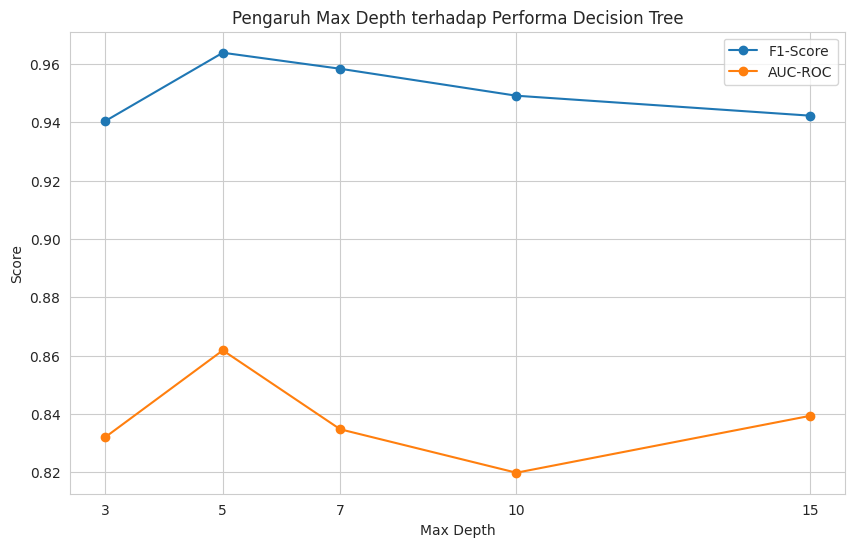

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    dt_results_df['max_depth'],
    dt_results_df['F1-Score'],
    marker='o',
    label='F1-Score'
)

plt.plot(
    dt_results_df['max_depth'],
    dt_results_df['AUC-ROC'],
    marker='o',
    label='AUC-ROC'
)

plt.xlabel('Max Depth')
plt.ylabel('Score')
plt.title('Pengaruh Max Depth terhadap Performa Decision Tree')
plt.xticks(depth_values)
plt.legend()
plt.grid(True)

plt.show()

## 2. Eksperimen Nilai K pada KNN

Pada eksperimen ini diuji beberapa nilai jumlah tetangga (`n_neighbors`)
pada algoritma KNN, yaitu K = 3, 5, 7, 9, dan 11.
Evaluasi dilakukan menggunakan F1-Score dan Recall.

In [ ]:
k_values = [3, 5, 7, 9, 11]

knn_results = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    knn_results.append({
        'K': k,
        'F1-Score': f1,
        'Recall': recall
    })

knn_results_df = pd.DataFrame(knn_results)

knn_results_df

,K,F1-Score,Recall
0,3,0.917266,0.935780
1,5,0.930851,0.963303
2,7,0.933333,0.976147
3,9,0.930070,0.976147
4,11,0.930192,0.977982


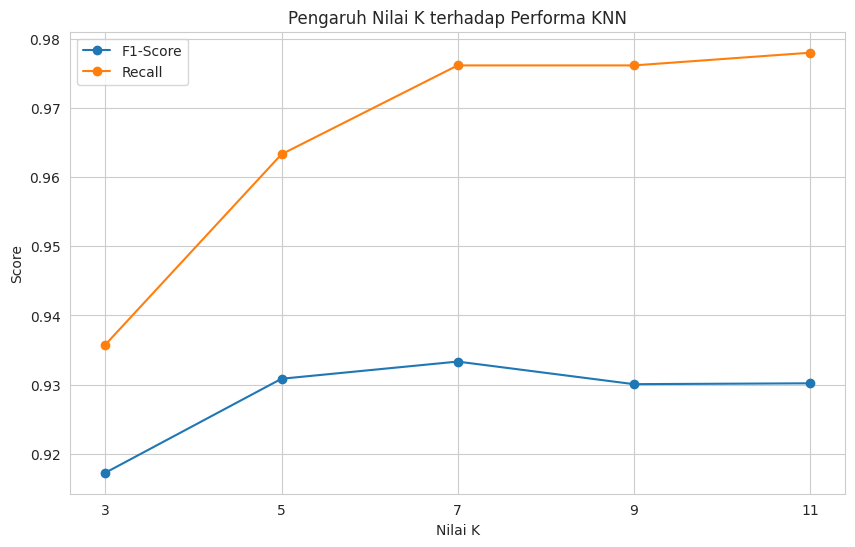

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    knn_results_df['K'],
    knn_results_df['F1-Score'],
    marker='o',
    label='F1-Score'
)

plt.plot(
    knn_results_df['K'],
    knn_results_df['Recall'],
    marker='o',
    label='Recall'
)

plt.xlabel('Nilai K')
plt.ylabel('Score')
plt.title('Pengaruh Nilai K terhadap Performa KNN')
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_k = knn_results_df.loc[
    knn_results_df['F1-Score'].idxmax()
]

print("K terbaik berdasarkan F1-Score:")
print(best_k)

K terbaik berdasarkan F1-Score:
K           7.000000
F1-Score    0.933333
Recall      0.976147
Name: 2, dtype: float64


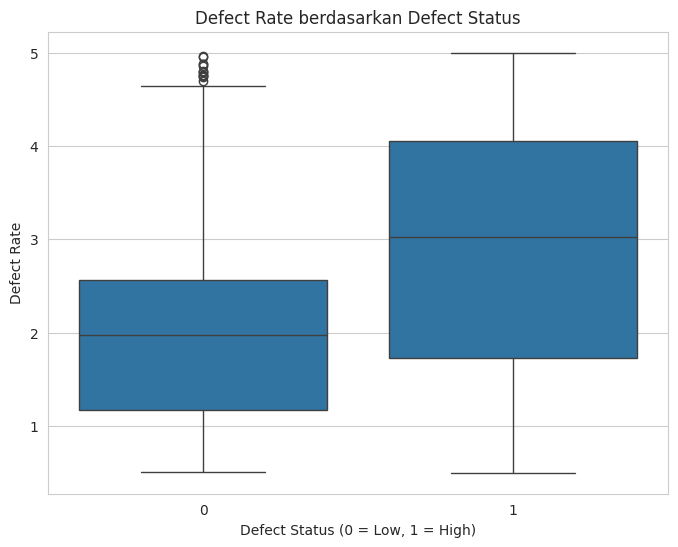

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='DefectStatus',
    y='DefectRate',
    data=df
)

plt.title('Defect Rate berdasarkan Defect Status')
plt.xlabel('Defect Status (0 = Low, 1 = High)')
plt.ylabel('Defect Rate')

plt.show()

### Interpretasi

Boxplot digunakan untuk membandingkan distribusi `DefectRate`
antara produk dengan status Low Defect dan High Defect.

Jika median dan distribusi `DefectRate` pada kedua kelas terlihat
berbeda, maka `DefectRate` dapat menjadi salah satu fitur yang
berhubungan dengan `DefectStatus`.

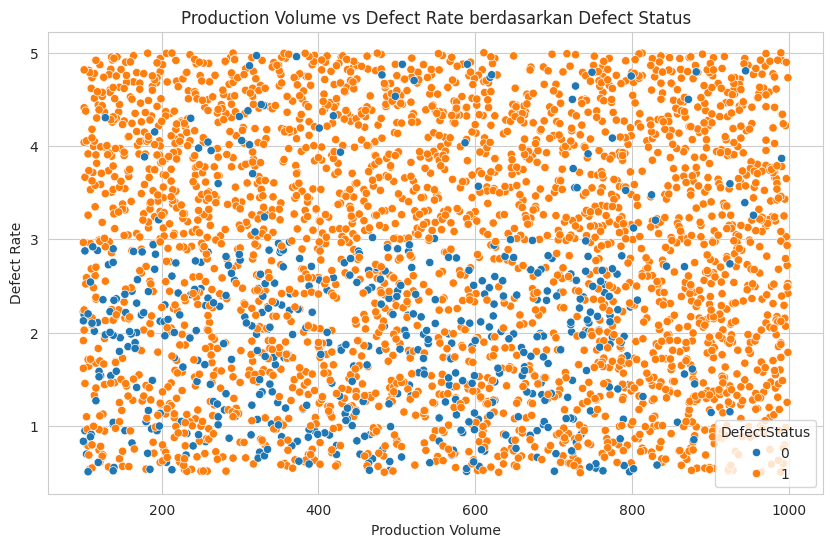

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='ProductionVolume',
    y='DefectRate',
    hue='DefectStatus'
)

plt.title(
    'Production Volume vs Defect Rate berdasarkan Defect Status'
)

plt.xlabel('Production Volume')
plt.ylabel('Defect Rate')

plt.show()

### Interpretasi

Scatter plot digunakan untuk melihat hubungan antara
`ProductionVolume` dan `DefectRate`, sekaligus melihat apakah
terdapat pola perbedaan berdasarkan `DefectStatus`.

Pola pemisahan atau pengelompokan titik berdasarkan status defect
dapat memberikan indikasi bahwa kedua fitur tersebut memiliki
informasi yang berguna dalam klasifikasi defect.

## 4. Pertanyaan Konsep

### 1. Mengapa accuracy tidak cukup untuk data imbalanced?

Accuracy tidak cukup digunakan sebagai satu-satunya metrik ketika
dataset memiliki class imbalance karena model dapat memperoleh
accuracy tinggi hanya dengan memprediksi kelas mayoritas.

Sebagai contoh, jika 84% data termasuk High Defect dan 16% termasuk
Low Defect, sebuah model yang selalu memprediksi High Defect dapat
memperoleh accuracy sekitar 84%, tetapi model tersebut tidak mampu
mengenali kelas Low Defect sama sekali.

Oleh karena itu, selain accuracy perlu digunakan Precision, Recall,
F1-Score, AUC-ROC, dan confusion matrix untuk mendapatkan gambaran
performa model yang lebih lengkap.

### 2. Apa perbedaan Precision dan Recall? Dalam konteks defect produk,
mana yang lebih penting?

Precision menunjukkan seberapa banyak prediksi positif yang benar
dari seluruh data yang diprediksi positif.

Recall menunjukkan seberapa banyak data positif aktual yang berhasil
ditemukan oleh model.

Dalam konteks prediksi defect, Recall menjadi metrik yang penting
karena False Negative berarti produk yang sebenarnya memiliki defect
diprediksi sebagai produk tidak defect. Kondisi tersebut dapat
menyebabkan produk defect lolos ke proses berikutnya atau bahkan
ke pasar.

Namun, Precision juga tetap penting karena False Positive dapat
menyebabkan produk yang sebenarnya baik dianggap defect sehingga
menimbulkan pemborosan.

### 3. Mengapa stratify=y penting pada train_test_split?

`stratify=y` digunakan untuk mempertahankan proporsi kelas target
antara data training dan data testing.

Hal ini penting karena dataset memiliki class imbalance. Tanpa
stratifikasi, pembagian data dapat menghasilkan proporsi kelas yang
berbeda antara training dan testing sehingga evaluasi model dapat
menjadi kurang representatif.

### 4. Apa itu overfitting? Bagaimana mendeteksinya dari tabel
perbandingan?

Overfitting terjadi ketika model terlalu menyesuaikan diri dengan
data training sehingga performanya pada data training sangat baik,
tetapi performanya pada data yang belum pernah dilihat lebih rendah.

Overfitting dapat dilihat dari perbedaan antara Train Accuracy dan
Test Accuracy. Jika Train Accuracy jauh lebih tinggi daripada
Test Accuracy, terdapat indikasi bahwa model mengalami overfitting.

Kolom `Overfit Gap` pada tabel perbandingan dapat digunakan untuk
melihat perbedaan tersebut.

### 5. Mengapa Random Forest sering lebih baik dari Decision Tree tunggal?

Random Forest merupakan ensemble yang menggabungkan banyak Decision
Tree. Setiap tree memberikan prediksi dan hasilnya digabungkan
untuk menghasilkan prediksi akhir.

Penggunaan banyak tree membuat Random Forest lebih robust dibandingkan
satu Decision Tree dan dapat mengurangi ketergantungan terhadap satu
struktur tree tertentu. Random Forest juga dapat menangkap pola yang
lebih kompleks dalam data.

## 5. Refleksi Pribadi

Setelah mengikuti praktikum Machine Learning mengenai prediksi defect
produk manufaktur, saya memahami bahwa Machine Learning tidak hanya
berkaitan dengan membuat model, tetapi juga membutuhkan proses
persiapan dan pemahaman data yang baik. Saya belajar bahwa tahap EDA
sangat penting untuk mengetahui karakteristik dataset, distribusi
target, missing value, serta hubungan antar fitur.

Bagian yang menurut saya cukup sulit adalah ...
Hal tersebut menjadi tantangan karena ...

Dari eksperimen Decision Tree, saya belajar bahwa perubahan nilai
`max_depth` dapat mempengaruhi performa model. Sementara itu, pada
KNN, perubahan nilai K juga menghasilkan performa yang berbeda.
Eksperimen tersebut membuat saya memahami bahwa pemilihan
hyperparameter merupakan bagian penting dalam pembangunan model.

Saya juga memahami bahwa accuracy tidak selalu cukup untuk menilai
model, terutama ketika dataset memiliki class imbalance. Dalam kasus
prediksi defect manufaktur, Recall menjadi penting karena model perlu
berusaha mendeteksi sebanyak mungkin produk yang berpotensi defect.

Jika diterapkan pada industri manufaktur, Machine Learning dapat
digunakan untuk membantu memprediksi risiko defect berdasarkan data
produksi. Hasil prediksi dapat digunakan sebagai informasi pendukung
bagi operator atau engineer untuk melakukan monitoring dan tindakan
preventif.

Secara keseluruhan, praktikum ini memberikan pengalaman bahwa proses
Machine Learning terdiri dari beberapa tahap yang saling berkaitan,
mulai dari memahami data, preprocessing, training model, evaluasi,
hingga interpretasi hasil.